<a href="https://colab.research.google.com/github/fidhanthanseel9-byte/-Data-Analytics-Mini-Project/blob/main/Copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (500, 10)

First 5 rows:
   OrderID       Date        Category   Region  Customer_Age  UnitPrice  \
0     1001 2024-01-01           Books     West            29     276.45   
1     1002 2024-01-02          Beauty    North            61     433.60   
2     1003 2024-01-03  Home & Kitchen  Central            53     369.62   
3     1004 2024-01-04          Beauty     East            21     265.42   
4     1005 2024-01-05          Beauty     East            22     435.40   

   Quantity  Discount Payment_Method  Satisfaction_Score  
0         4      0.20     Debit Card                   5  
1         6      0.15         PayPal                   1  
2         6      0.15     Debit Card                   1  
3         2      0.10            UPI                   2  
4         8      0.20     Debit Card                   4  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null C

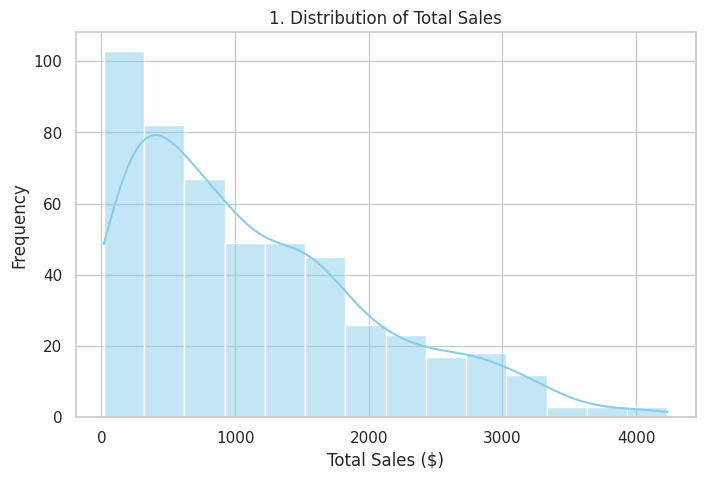

/tmp/ipykernel_871/988781346.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x="Category", y="Total_Sales", palette="viridis")


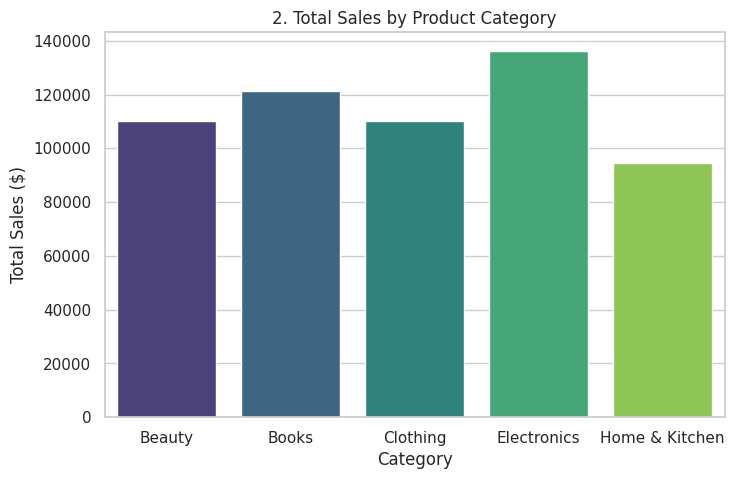

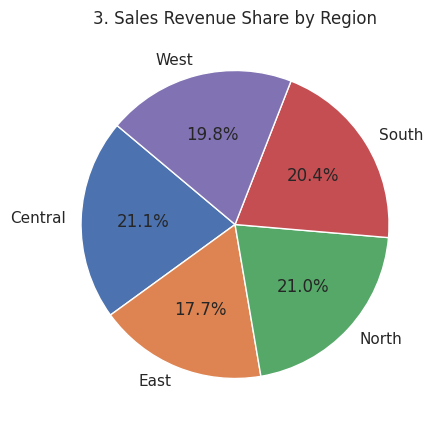

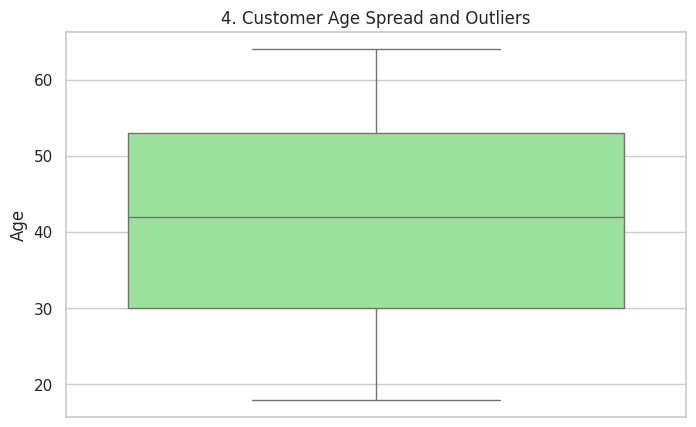

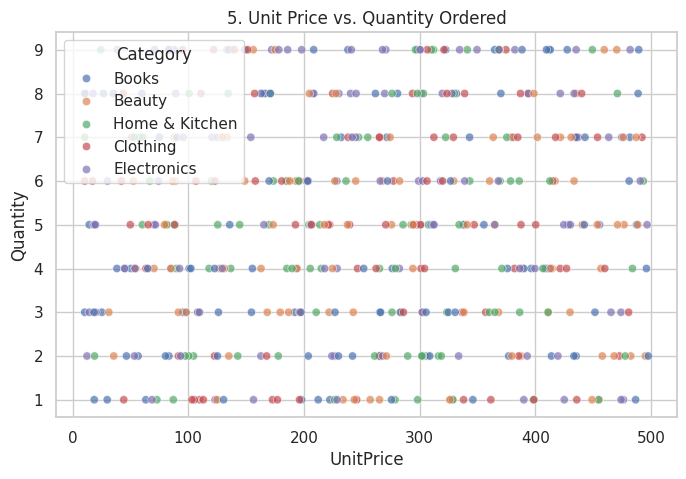

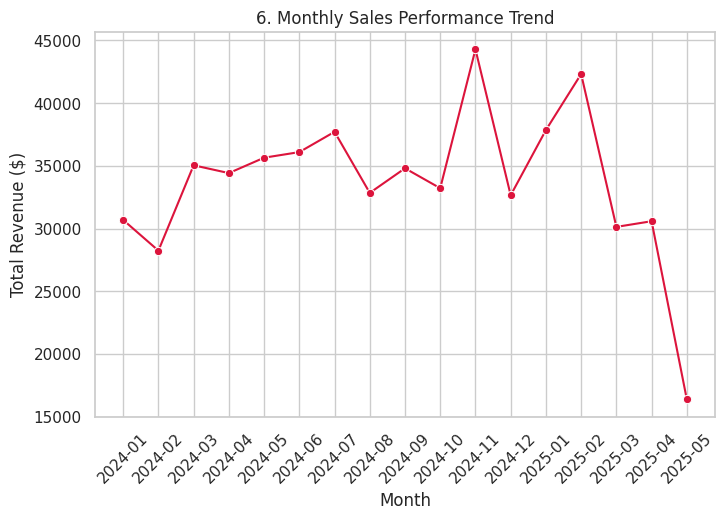

/tmp/ipykernel_871/988781346.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


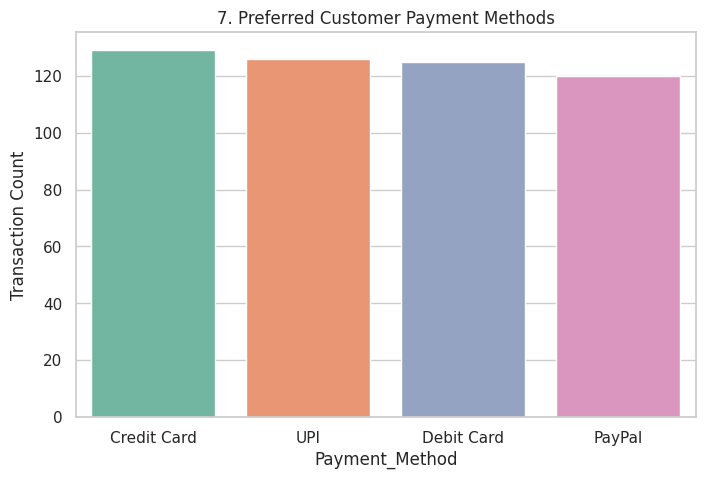

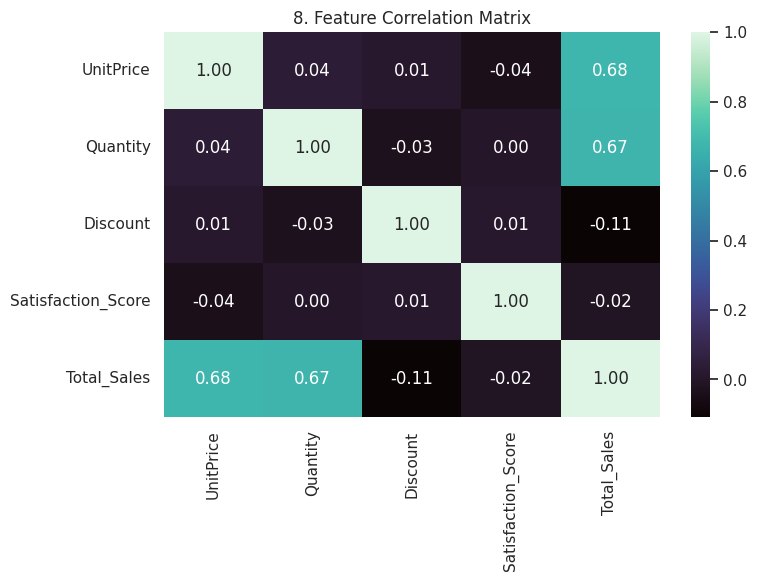

/tmp/ipykernel_871/988781346.py:145: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


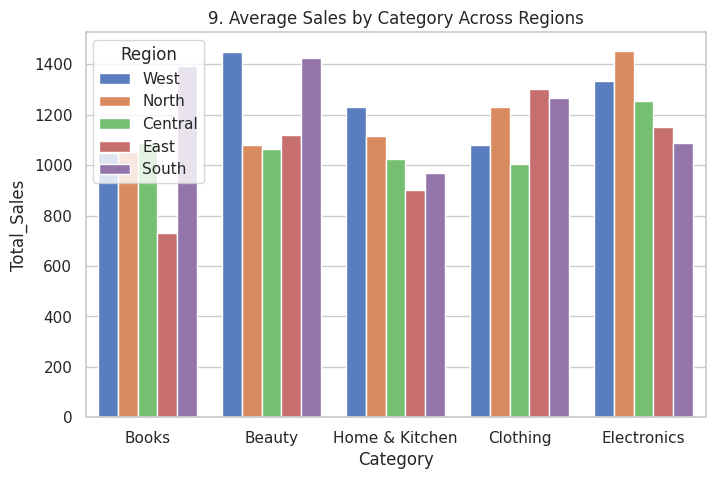

/tmp/ipykernel_871/988781346.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


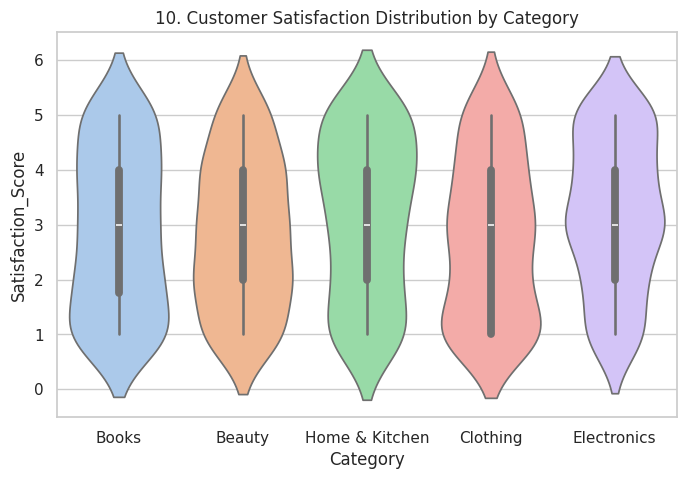

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# --- TASK 1: DATA CREATION & INITIAL OVERVIEW ---
# Generating a sample E-Commerce dataset (500 records, 10 columns)
np.random.seed(42)
n_rows = 500

data = {
    "OrderID": range(1001, 1001 + n_rows),
    "Date": pd.date_range(start="2024-01-01", periods=n_rows, freq="D"),
    "Category": np.random.choice(
        ["Electronics", "Clothing", "Home & Kitchen", "Books", "Beauty"],
        n_rows,
    ),
    "Region": np.random.choice(
        ["North", "South", "East", "West", "Central"], n_rows
    ),
    "Customer_Age": np.random.randint(18, 65, size=n_rows),
    "UnitPrice": np.random.uniform(10.0, 500.0, size=n_rows).round(2),
    "Quantity": np.random.randint(1, 10, size=n_rows),
    "Discount": np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20], n_rows),
    "Payment_Method": np.random.choice(
        ["Credit Card", "PayPal", "Debit Card", "UPI"], n_rows
    ),
    "Satisfaction_Score": np.random.randint(1, 6, size=n_rows),
}

df = pd.DataFrame(data)

# Introduce a few missing values to demonstrate cleaning
df.loc[10:15, "UnitPrice"] = np.nan

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()

# --- TASK 2: DATA PRE-PROCESSING ---
# 1. Handle Missing Values
df["UnitPrice"] = df["UnitPrice"].fillna(df["UnitPrice"].median())

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Create Derived Columns
df["Total_Sales"] = (df["UnitPrice"] * df["Quantity"]) * (1 - df["Discount"])
df["Month"] = df["Date"].dt.strftime("%Y-%m")

# --- TASK 3: 10 REQUIRED VISUALIZATIONS ---

# Visual 1: Sales Distribution (Histogram)
plt.figure()
sns.histplot(df["Total_Sales"], kde=True, color="skyblue")
plt.title("1. Distribution of Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Frequency")
plt.show()

# Visual 2: Category Sales (Bar Chart)
plt.figure()
cat_sales = df.groupby("Category")["Total_Sales"].sum().reset_index()
sns.barplot(data=cat_sales, x="Category", y="Total_Sales", palette="viridis")
plt.title("2. Total Sales by Product Category")
plt.ylabel("Total Sales ($)")
plt.show()

# Visual 3: Regional Sales (Pie Chart)
plt.figure()
region_sales = df.groupby("Region")["Total_Sales"].sum()
plt.pie(
    region_sales, labels=region_sales.index, autopct="%1.1f%%", startangle=140
)
plt.title("3. Sales Revenue Share by Region")
plt.show()

# Visual 4: Customer Age Distribution (Box Plot)
plt.figure()
sns.boxplot(y=df["Customer_Age"], color="lightgreen")
plt.title("4. Customer Age Spread and Outliers")
plt.ylabel("Age")
plt.show()

# Visual 5: Price vs. Quantity (Scatter Plot)
plt.figure()
sns.scatterplot(
    data=df,
    x="UnitPrice",
    y="Quantity",
    hue="Category",
    alpha=0.7,
)
plt.title("5. Unit Price vs. Quantity Ordered")
plt.show()

# Visual 6: Monthly Sales Trend (Line Chart)
plt.figure()
monthly_trend = df.groupby("Month")["Total_Sales"].sum().reset_index()
sns.lineplot(
    data=monthly_trend,
    x="Month",
    y="Total_Sales",
    marker="o",
    color="crimson",
)
plt.xticks(rotation=45)
plt.title("6. Monthly Sales Performance Trend")
plt.ylabel("Total Revenue ($)")
plt.show()

# Visual 7: Payment Method Breakdown (Count Plot)
plt.figure()
sns.countplot(
    data=df,
    x="Payment_Method",
    palette="Set2",
    order=df["Payment_Method"].value_counts().index,
)
plt.title("7. Preferred Customer Payment Methods")
plt.ylabel("Transaction Count")
plt.show()

# Visual 8: Correlation Matrix (Heatmap)
plt.figure()
numeric_cols = [
    "UnitPrice",
    "Quantity",
    "Discount",
    "Satisfaction_Score",
    "Total_Sales",
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="mako", fmt=".2f")
plt.title("8. Feature Correlation Matrix")
plt.show()

# Visual 9: Category vs Region Sales (Grouped Bar Chart)
plt.figure()
sns.barplot(
    data=df, x="Category", y="Total_Sales", hue="Region", ci=None, palette="muted"
)
plt.title("9. Average Sales by Category Across Regions")
plt.show()

# Visual 10: Satisfaction Score by Category (Violin Plot)
plt.figure()
sns.violinplot(
    data=df, x="Category", y="Satisfaction_Score", palette="pastel"
)
plt.title("10. Customer Satisfaction Distribution by Category")
plt.show()

# Save processed data for upload
df.to_csv("Cleaned_data.csv", index=False)